In [1]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn
%pip install IPython.display
%pip install scipy
%pip install random


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 2.0 MB/s eta 0:00:00 MB/s eta 0:00:01:01

[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 1.8 MB/s eta 0:00:00 MB/s eta 0:00:01:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 3.1 MB/s eta 0:00:003.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 3.4 MB/s eta 0:00:003.5 MB/s eta 0:00:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

[notice] A new release 

In [32]:
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy as sp
from IPython.display import display, clear_output
import matplotlib.animation as animation
from matplotlib.colors import Normalize
import time
import pandas as pd
import random


In [33]:
def get_truncated_normal(mean=0.5, sd=0.1, low=0, high=1, rng=None):
    """Return a single sample from a truncated normal distribution.

    Parameters
    ----------
    mean : float
        Mean of the underlying normal.
    sd : float
        Standard deviation of the underlying normal.
    low : float
        Lower bound of the truncation.
    high : float
        Upper bound of the truncation.
    rng : np.random.Generator, optional
        Random number generator.  If None a new default_rng() is created.

    Returns
    -------
    float
        One sample from TruncNorm(mean, sd, [low, high]).
    """
    a = (low - mean) / sd
    b = (high - mean) / sd
    return sp.stats.truncnorm(a, b, loc=mean, scale=sd).rvs(random_state=rng)


def gini(x):
    """Standard Gini coefficient for a 1-D array of non-negative wealth values.

    Parameters
    ----------
    x : array-like
        Non-negative wealth values.

    Returns
    -------
    float
        Gini coefficient in [0, 1].
    """
    x = np.asarray(x, dtype=float)
    if x.size == 0 or np.all(x == 0):
        return 0.0
    x = np.sort(x)
    n = x.size
    cum = np.cumsum(x)
    return (2 * np.sum((np.arange(1, n + 1)) * x) - (n + 1) * cum[-1]) / (n * cum[-1])


def initialize_bundle(n_goods, mode="uniform", rng=None, low=5.0, high=25.0):
    """Return a length-n_goods ndarray of initial holdings.

    Parameters
    ----------
    n_goods : int
        Number of goods.
    mode : str
        One of "single_random", "uniform", or "empty".
        - "single_random": one good gets a uniform[low, high] amount, others 0.
        - "uniform":       every good gets uniform[low, high] independently.
        - "empty":         all zeros.
    rng : np.random.Generator, optional
        Random number generator.
    low : float
        Lower bound for uniform draws.
    high : float
        Upper bound for uniform draws.

    Returns
    -------
    np.ndarray
        Shape (n_goods,).
    """
    if rng is None:
        rng = np.random.default_rng()
    if mode == "single_random":
        bundle = np.zeros(n_goods)
        g = rng.integers(n_goods)
        bundle[g] = rng.uniform(low, high)
        return bundle
    elif mode == "uniform":
        return rng.uniform(low, high, size=n_goods)
    elif mode == "empty":
        return np.zeros(n_goods)
    raise ValueError(f"Unknown mode: {mode}")


In [34]:
from matplotlib.pylab import array


class Agent:
    """An agent in the Sugarscape model.

    Parameters
    ----------
    id : int
        Unique agent identifier.
    preferences : np.ndarray
        Shape (n_goods,) of Cobb-Douglas preference weights (alphas).
    bundle : np.ndarray
        Shape (n_goods,) initial holdings of each good.
    vision : int
        Chebyshev radius the agent can see and move within.
    position : tuple[int, int]
        (row, col) grid position.
    metabolic_rate : np.ndarray
        Shape (n_goods,) per-good consumption rate per step.
    """

    

    def __init__(self, id, preferences, bundle, vision, position, metabolic_rate):
        self.id = id
        self.preferences = np.asarray(preferences, dtype=float)
        self.bundle = np.asarray(bundle, dtype=float)
        self.vision = vision
        self.position = position
        self.metabolic_rate = np.asarray(metabolic_rate, dtype=float)
        self.trade_history = {'Price': [], 'Quantity Bought': [], 'Quantity Sold': [], 'Good Given': [], 'Good Received': [], 'Partner ID': []}

    # ------------------------------------------------------------------
    # Welfare / preferences
    # ------------------------------------------------------------------

    def utility_function(self, bundle):
        """Cobb-Douglas welfare: U = prod(bundle[g] ** (alpha[g] / sum(alpha))).

        Parameters
        ----------
        bundle : np.ndarray
            Shape (n_goods,) resource quantities.

        Returns
        -------
        float
            Welfare value (>= 0).  Zero if any bundle entry is <= 0.
        """
        alpha = self.preferences / self.preferences.sum()
        return float(np.prod(np.power(bundle, alpha)))

    # ------------------------------------------------------------------
    # Trade helpers (not wired up yet)
    # ------------------------------------------------------------------

    def _calc_mrs(self, good_i, good_j):
        """Marginal rate of substitution: units of good j per unit of good i.

        Parameters
        ----------
        good_i : int
            Index of the good being given up.
        good_j : int
            Index of the good being received.

        Returns
        -------
        float
            MRS value.
        """
        weight_good_i = self.preferences[good_i]
        weight_good_j = self.preferences[good_j]
        quantity_good_i = self.bundle[good_i]
        quantity_good_j = self.bundle[good_j]

        if quantity_good_i <= 0:
            return np.inf  #
         
        if quantity_good_j <= 0:
            return 0.0  

        return (quantity_good_j / weight_good_j) / (quantity_good_i / weight_good_i)
    

    #
    # Trade
    #


    def trade(self, other_agent, good_i, good_j):
        """Attempt to trade with another agent.

        Parameters
        ----------
        other_agent : Agent
            The agent to trade with.

        
        """
        while True:
            mrs_self = self._calc_mrs(good_i, good_j)
            mrs_other = other_agent._calc_mrs(good_i, good_j)
            #Higher mrs means more of good i per unit of good j, so self wants to give up good i and get good j, while other wants the opposite.  If they're equal, no mutually beneficial trade is possible.

            if abs(mrs_self - mrs_other) < 1e-6:
                break

            price = np.sqrt(mrs_self * mrs_other)

            q_buy, q_sell = 0, 0

            if price >= 1:
                q_buy = 1
                q_sell = price
            else:
                q_buy = 1 / price
                q_sell = 1
            



            if mrs_self > mrs_other:
                buyer = self
                seller = other_agent
            else:
                buyer = other_agent
                seller = self

            if seller.bundle[good_i] < q_buy or buyer.bundle[good_j] < q_sell:
                return
            
            new_seller_bundle = seller.bundle - [q_buy, -q_sell]
            new_buyer_bundle = buyer.bundle + [q_buy, -q_sell]


            if buyer.utility_function(new_buyer_bundle) <= buyer.utility_function(buyer.bundle) or seller.utility_function(new_seller_bundle) <= seller.utility_function(seller.bundle):
                return

            new_mrs_buyer = buyer._calc_mrs(good_i, good_j)
            new_mrs_seller = seller._calc_mrs(good_i, good_j)

            if new_mrs_buyer <= new_mrs_seller:
                return
            

            seller.bundle = new_seller_bundle
            buyer.bundle = new_buyer_bundle

            self.trade_history['Price'].append(price)
            self.trade_history['Quantity Bought'].append(q_buy)
            self.trade_history['Quantity Sold'].append(q_sell)
            self.trade_history['Good Given'].append(good_i)
            self.trade_history['Good Received'].append(good_j)


        return

    # ------------------------------------------------------------------
    # Movement & harvest
    # ------------------------------------------------------------------

    def move(self, env, agents, rng):
        """Move to the best reachable cell within vision and harvest its resources.

        Best is defined as highest prospective welfare = utility_function(self.bundle
        + resources_at_cell).  Occupied cells are skipped.  Ties broken first by
        Manhattan distance (closest wins), then randomly.

        Parameters
        ----------
        env : Environment
            The environment object.
        agents : list[Agent]
            All living agents (used to detect occupied cells).
        rng : np.random.Generator
            Random number generator for tie-breaking.
        """
        r, c = self.position
        v = self.vision

        # Collect positions of other agents for collision detection
        occupied = {a.position for a in agents if a is not self}

        # Build candidate cell grid (clipped to env bounds)
        r_min = max(0, r - v)
        r_max = min(env.H - 1, r + v)
        c_min = max(0, c - v)
        c_max = min(env.W - 1, c + v)

        best_utility = -np.inf
        best_distance = np.inf
        best_cells = []

        for nr in range(r_min, r_max + 1):
            for nc in range(c_min, c_max + 1):
                if (nr, nc) in occupied:
                    continue
                prospective = self.bundle + env.landscape[:, nr, nc]
                u = self.utility_function(prospective)
                dist = abs(nr - r) + abs(nc - c)
                if u > best_utility or (u == best_utility and dist < best_distance):
                    best_utility = u
                    best_distance = dist
                    best_cells = [(nr, nc)]
                elif u == best_utility and dist == best_distance:
                    best_cells.append((nr, nc))

        if best_cells:
            idx = rng.integers(len(best_cells))
            new_pos = best_cells[idx]
        else:
            new_pos = self.position

        self.position = new_pos

        # Harvest entire stack at new position
        nr, nc = new_pos
        self.bundle += env.landscape[:, nr, nc]
        env.landscape[:, nr, nc] = 0.0

    # ------------------------------------------------------------------
    # Metabolism
    # ------------------------------------------------------------------

    def metabolism(self):
        """Subtract per-good metabolic rate from bundle.

        Returns
        -------
        bool
            True if agent should die (any good exhausted), False otherwise.
        """
        self.bundle -= self.metabolic_rate
        return bool(np.any(self.bundle <= 0))

    # ------------------------------------------------------------------
    # Neighbors
    # ------------------------------------------------------------------

    def get_neighbors_in_vision(self, agents):
        """Return list of other agents within Chebyshev distance <= self.vision.

        Parameters
        ----------
        agents : list[Agent]
            All living agents.

        Returns
        -------
        list[Agent]
            Agents (excluding self) within vision radius.
        """
        if not agents:
            return []
        positions = np.array([a.position for a in agents])
        self_pos = np.array(self.position)
        chebyshev = np.max(np.abs(positions - self_pos), axis=1)
        in_range = (chebyshev <= self.vision) & (chebyshev > 0)
        return [a for a, ok in zip(agents, in_range) if ok]


In [35]:
def make_landscape(H, W, resource_fns, max_resource):
    """Build a (n_goods, H, W) landscape array from a list of 2-D functions.

    Parameters
    ----------
    H : int
        Grid height (rows).
    W : int
        Grid width (columns).
    resource_fns : list[callable]
        Each fn maps (x, y) arrays in [0,1]^2 to a non-negative scalar array.
    max_resource : float
        Peak value each good's landscape is normalised to.

    Returns
    -------
    np.ndarray
        Shape (n_goods, H, W).
    """
    n_goods = len(resource_fns)
    y, x = np.meshgrid(np.linspace(0, 1, H), np.linspace(0, 1, W), indexing='ij')
    landscape = np.zeros((n_goods, H, W))
    for g, fn in enumerate(resource_fns):
        z = np.clip(fn(x, y), 0, None)
        landscape[g] = (z / z.max() * max_resource) if z.max() > 0 else z
    return landscape


class Environment:
    """The resource landscape.

    Parameters
    ----------
    H : int
        Grid height.
    W : int
        Grid width.
    resource_fns : list[callable]
        One function per good; each maps (x, y) in [0,1]^2 to resource density.
    max_resource : float
        Maximum resource level per cell per good.
    """

    def __init__(self, H, W, resource_fns, max_resource=4):
        self.n_goods = len(resource_fns)
        self.H = H
        self.W = W
        self.max_landscape = make_landscape(H, W, resource_fns, max_resource)
        self.landscape = self.max_landscape.copy()

    def is_valid_position(self, pos):
        """Return True if (row, col) is within the grid.

        Parameters
        ----------
        pos : tuple[int, int]
            (row, col) to check.

        Returns
        -------
        bool
        """
        r, c = pos
        return 0 <= r < self.H and 0 <= c < self.W

    def get_resources_at(self, pos):
        """Return length-n_goods vector of current resources at pos.

        Parameters
        ----------
        pos : tuple[int, int]
            (row, col).

        Returns
        -------
        np.ndarray
            Shape (n_goods,).
        """
        r, c = pos
        return self.landscape[:, r, c].copy()

    def regrow(self, growth_rate):
        """Logistic-style regrowth toward max_landscape, vectorised over all goods.

        Parameters
        ----------
        growth_rate : float
            Fraction of deficit to recover each step.
        """
        deficit = self.max_landscape - self.landscape
        self.landscape = np.clip(
            self.landscape + growth_rate * deficit, 0, self.max_landscape
        )


def make_anti_correlated_2good(H=50, W=50, sigma=0.25, max_resource=4):
    """Standard 2-good Sugarscape: sugar peaks UL+LR, spice peaks UR+LL.

    Parameters
    ----------
    H : int
        Grid height.
    W : int
        Grid width.
    sigma : float
        Width of each Gaussian peak.
    max_resource : float
        Peak resource level (passed to make_landscape).

    Returns
    -------
    list[callable]
        [sugar_fn, spice_fn] suitable for passing to Environment or run().
    """
    g = lambda x, y, cx, cy: np.exp(-((x - cx) ** 2 + (y - cy) ** 2) / (2 * sigma ** 2))
    sugar_fn = lambda x, y: g(x, y, 0.2, 0.2) + g(x, y, 0.8, 0.8)
    spice_fn = lambda x, y: g(x, y, 0.2, 0.8) + g(x, y, 0.8, 0.2)
    return [sugar_fn, spice_fn]


In [36]:
def initialize(n_agents, env_size, resource_fns, max_resource,
               metabolic_rate_mean, preferences_mean, vision,
               n_goods, bundle_mode, rng):
    """Build the environment and a list of agents with random positions and parameters.

    Parameters
    ----------
    n_agents : int
        Number of agents to create.
    env_size : tuple[int, int]
        (H, W) grid dimensions.
    resource_fns : list[callable]
        One landscape function per good.
    max_resource : float
        Peak resource value.
    metabolic_rate_mean : float
        Mean metabolic rate used when sampling per-agent, per-good rates.
    preferences_mean : list[float] or None
        Mean preference weights per good.  If None, defaults to uniform [0.5]*n_goods.
    vision : int
        Agent vision radius (Chebyshev).
    n_goods : int
        Number of goods.
    bundle_mode : str
        Initial bundle mode; passed to initialize_bundle.
    rng : np.random.Generator
        Seeded random number generator.

    Returns
    -------
    tuple[list[Agent], Environment]
    """
    env = Environment(env_size[0], env_size[1], resource_fns, max_resource)

    if preferences_mean is None:
        preferences_mean = [0.5] * n_goods

    agents = []
    occupied = set()
    for agent_id in range(n_agents):
        # Random non-colliding starting position
        while True:
            r = rng.integers(0, env.H)
            c = rng.integers(0, env.W)
            if (r, c) not in occupied:
                occupied.add((r, c))
                break
        position = (int(r), int(c))

        stochastic_preferences = np.array([
            get_truncated_normal(preferences_mean[g], sd=0.5, low=0.0, high=1.0, rng=rng)
            for g in range(n_goods)
        ])

        metabolic_rate = np.array([
            get_truncated_normal(metabolic_rate_mean, sd=0.3, low=0.1, high=4.0, rng=rng)
            for _ in range(n_goods)
        ])

        bundle = initialize_bundle(n_goods, mode=bundle_mode, rng=rng)

        agents.append(Agent(agent_id, stochastic_preferences, bundle,
                            vision, position, metabolic_rate))
    return agents, env


In [ ]:



def update(agents, env, regrowth_rate, rng, trade = True, reproduction_enabled=False):
    """One simulation step.

    Steps
    -----
    1. Each agent moves (and harvests resources at the destination).
    2. Each agent metabolizes; dead agents are collected.
    3. Dead agents are removed from the list.
    4. Resources regrow.
    5. Reproduction is skipped while reproduction_enabled=False.

    Parameters
    ----------
    agents : list[Agent]
        Living agents (mutated in-place: dead agents are removed).
    env : Environment
        The environment.
    regrowth_rate : float
        Fraction of resource deficit recovered per step.
    rng : np.random.Generator
        Random number generator.
    reproduction_enabled : bool
        If True, enable reproduction (not yet implemented).

    Returns
    -------
    int
        Number of deaths this step.
    """
    randomized_agents = random.sample(agents, len(agents))

    # 1. Movement + harvest
    for a in randomized_agents:
        a.move(env, agents, rng)

    if trade:
        for a in agents:
            a.trade_history = {'Price': [], 'Quantity Bought': [], 'Quantity Sold': [], 'Good Given': [], 'Good Received': [], 'Partner ID': []}

        for a in randomized_agents:
            for neighbor in a.get_neighbors_in_vision(agents):
                if neighbor.id > a.id:  # Avoid double-counting pairs
                    a.trade(neighbor, good_i=0, good_j=1)  # Example: trade good 0 for good 1

    # 2. Metabolism — collect deaths without mutating the list mid-loop
    to_remove = []
    for a in randomized_agents:
        if a.metabolism():
            to_remove.append(a)

    # 3. Apply deaths
    for a in to_remove:
        agents.remove(a)

    # 4. Regrow resources
    env.regrow(regrowth_rate)

    # 5. Reproduction (disabled by default)
    if reproduction_enabled:
        pass  # placeholder for future implementation

    return len(to_remove)


In [ ]:
def run(time_steps, n_agents, env_size, resource_fns,
        max_resource=4, regrowth_rate=0.05,
        metabolic_rate_mean=1.0, preferences_mean=None,
        vision=6, bundle_mode="single_random", seed=0, trade = True,
        reproduction_enabled=False, record=False, live=False):
    """Run the Sugarscape simulation and return a per-step summary DataFrame.

    Parameters
    ----------
    time_steps : int
        Number of simulation steps.
    n_agents : int
        Initial number of agents.
    env_size : tuple[int, int]
        (H, W) grid dimensions.
    resource_fns : list[callable]
        One landscape function per good.
    max_resource : float
        Peak resource value per cell.
    regrowth_rate : float
        Fraction of resource deficit recovered per step.
    metabolic_rate_mean : float
        Mean metabolic rate used when initialising agents.
    preferences_mean : list[float] or None
        Mean preference weights per good.
    vision : int
        Agent vision radius.
    bundle_mode : str
        Initial bundle mode ("single_random", "uniform", or "empty").
    seed : int or None
        RNG seed for reproducibility.
    reproduction_enabled : bool
        Whether to allow reproduction.

    Returns
    -------
    pd.DataFrame or tuple
        DataFrame (one row per time step) when ``record=False``; when
        ``record=True``, a tuple ``(df, agents_history, env_history)``.
    """
    rng = np.random.default_rng(seed)
    n_goods = len(resource_fns)

    agents, env = initialize(
        n_agents, env_size, resource_fns, max_resource,
        metabolic_rate_mean, preferences_mean, vision,
        n_goods, bundle_mode, rng
    )

    records = []
    env_history = []
    agents_history = []
    trade_history = []

    for t in range(time_steps):
        deaths = update(agents, env, regrowth_rate, rng, trade,
                        reproduction_enabled=reproduction_enabled)

        if record:
            env_history.append(env.landscape.copy())
            positions = np.array([a.position for a in agents]) if agents else np.empty((0, 2), dtype=int)
            wealths = np.array([a.bundle.sum() for a in agents]) if agents else np.array([])
            agents_history.append((positions, wealths))
            for a in agents:
                trade_history.append(a.trade_history)

        if live:
            live_view(env, agents, t)

        if agents:
            utilities = np.array([a.utility_function(a.bundle) for a in agents])
            wealth = np.array([a.bundle.sum() for a in agents])
            mean_utility = float(np.mean(utilities))
            gini_wealth = gini(wealth)
            mean_bundle_per_good = [
                float(np.mean([a.bundle[g] for a in agents]))
                for g in range(n_goods)
            ]
        else:
            mean_utility = 0.0
            gini_wealth = 0.0
            mean_bundle_per_good = [0.0] * n_goods

        records.append({
            't': t,
            'n_alive': len(agents),
            'deaths_this_step': deaths,
            'mean_utility': mean_utility,
            'gini_wealth': gini_wealth,
            'mean_bundle_per_good': mean_bundle_per_good,
            'trade_history': trade_history[-1] 
        })

    df = pd.DataFrame(records)
    if record:
        return df, agents_history, env_history
    return df


SyntaxError: invalid syntax. Perhaps you forgot a comma? (1445130450.py, line 4)

In [39]:
def _make_fig(env):
    """Build a figure with one subplot per good, ready for animation."""
    cmaps = ['YlOrBr', 'BuGn', 'PuRd', 'Blues', 'Greens', 'Oranges', 'Purples']
    fig, axes = plt.subplots(1, env.n_goods, figsize=(5 * env.n_goods, 5),
                             squeeze=False)
    axes = axes[0]
    ims, scatters = [], []
    for g, ax in enumerate(axes):
        im = ax.imshow(env.landscape[g], cmap=cmaps[g % len(cmaps)],
                       vmin=0, vmax=env.max_landscape[g].max(),
                       interpolation='nearest', origin='upper')
        sc = ax.scatter([], [], s=30, c=[], cmap='plasma',
                        edgecolors='black', linewidths=0.5,
                        vmin=0, vmax=1)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(f"Good {g}")
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        ims.append(im)
        scatters.append(sc)
    # Shared colorbar for agent wealth at the far right
    sm = plt.cm.ScalarMappable(cmap='plasma', norm=Normalize(vmin=0, vmax=1))
    sm.set_array([])
    fig.colorbar(sm, ax=axes.tolist(), fraction=0.02, pad=0.04, label='Agent wealth')
    fig.subplots_adjust(right=0.8, wspace=0.25)
    return fig, axes, ims, scatters


def animate(df_log, agents_history, env_history, save_path=None):
    """Return a FuncAnimation replaying the recorded simulation history.

    Parameters
    ----------
    df_log : pd.DataFrame
        Summary DataFrame returned by run().
    agents_history : list of (positions, wealths) tuples
        As captured by run(record=True).
    env_history : list of np.ndarray
        Landscape snapshots as captured by run(record=True).
    save_path : str or None
        If given, save the animation (use .gif for pillow, .mp4 for ffmpeg).

    Returns
    -------
    matplotlib.animation.FuncAnimation
    """
    # Build a throw-away env shell to pass to _make_fig (only needs n_goods,
    # max_landscape, landscape shape — no live simulation state required).
    class _FakeEnv:
        pass
    fake_env = _FakeEnv()
    fake_env.n_goods = env_history[0].shape[0]
    fake_env.landscape = env_history[0].copy()
    fake_env.max_landscape = env_history[0].copy()
    for snap in env_history:
        fake_env.max_landscape = np.maximum(fake_env.max_landscape, snap)

    fig, axes, ims, scatters = _make_fig(fake_env)
    title = fig.suptitle("t = 0")

    def _update(frame):
        snap = env_history[frame]
        positions, wealths = agents_history[frame]
        vmax = float(wealths.max()) if len(wealths) > 0 else 1.0
        for g, (im, sc) in enumerate(zip(ims, scatters)):
            im.set_data(snap[g])
            if len(positions) > 0:
                sc.set_offsets(positions[:, ::-1])  # (col, row) = (x, y)
                sc.set_array(wealths)
                sc.set_clim(0, vmax)
            else:
                sc.set_offsets(np.empty((0, 2)))
                sc.set_array(np.array([]))
        title.set_text(f"t = {frame}")
        return ims + scatters + [title]

    anim = animation.FuncAnimation(fig, _update, frames=len(env_history),
                                   interval=50, blit=False)
    if save_path is not None:
        writer = 'pillow' if save_path.endswith('.gif') else 'ffmpeg'
        anim.save(save_path, writer=writer, fps=20)
    return anim


def live_view(env, agents, t):
    """Update (or create) a persistent figure showing the current simulation state.

    Call once per simulation step when ``live=True`` is passed to run().
    """
    if not hasattr(live_view, '_fig') or live_view._fig is None:
        live_view._fig, live_view._axes, live_view._ims, live_view._scatters = _make_fig(env)
        live_view._title = live_view._fig.suptitle(f"t = {t}")
        plt.ion()

    snap = env.landscape
    positions = np.array([a.position for a in agents]) if agents else np.empty((0, 2), dtype=int)
    wealths = np.array([a.bundle.sum() for a in agents]) if agents else np.array([])
    vmax = float(wealths.max()) if len(wealths) > 0 else 1.0

    for g, (im, sc) in enumerate(zip(live_view._ims, live_view._scatters)):
        im.set_data(snap[g])
        if len(positions) > 0:
            sc.set_offsets(positions[:, ::-1])
            sc.set_array(wealths)
            sc.set_clim(0, vmax)
        else:
            sc.set_offsets(np.empty((0, 2)))
            sc.set_array(np.array([]))

    live_view._title.set_text(f"t = {t}")
    live_view._fig.canvas.draw_idle()
    clear_output(wait=True)
    display(live_view._fig)
    plt.pause(0.01)


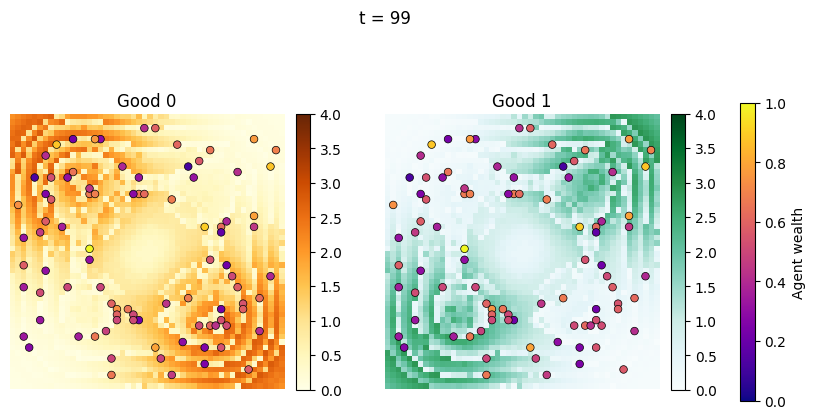

,t,n_alive,deaths_this_step,mean_utility,gini_wealth,mean_bundle_per_good,trade_history
0,0,95,5,8.546583,0.267616,"[8.433000700564053, 8.730826918090258]","{'Price': [], 'Quantity Bought': [], 'Quantity..."
1,1,95,0,10.412774,0.230514,"[9.98270883292423, 9.583689453895987]","{'Price': [], 'Quantity Bought': [], 'Quantity..."
2,2,93,2,12.092869,0.200574,"[11.59896038611082, 10.70314886294532]","{'Price': [], 'Quantity Bought': [], 'Quantity..."
3,3,92,1,13.222967,0.183958,"[12.768168363459278, 11.794932722866527]","{'Price': [], 'Quantity Bought': [], 'Quantity..."
4,4,92,0,14.478332,0.170868,"[13.969675045247962, 12.842542809511077]","{'Price': [], 'Quantity Bought': [], 'Quantity..."
...,...,...,...,...,...,...,...
95,95,91,1,68.146608,0.205078,"[63.49020066912185, 60.86961642210487]","{'Price': [], 'Quantity Bought': [], 'Quantity..."
96,96,91,0,68.592809,0.205701,"[63.873547150631794, 61.309335535174824]","{'Price': [], 'Quantity Bought': [], 'Quantity..."
97,97,91,0,69.023952,0.206561,"[64.25508348359894, 61.70838369328627]","{'Price': [], 'Quantity Bought': [], 'Quantity..."
98,98,91,0,69.505370,0.207029,"[64.7452804902353, 62.08805212074073]","{'Price': [], 'Quantity Bought': [], 'Quantity..."


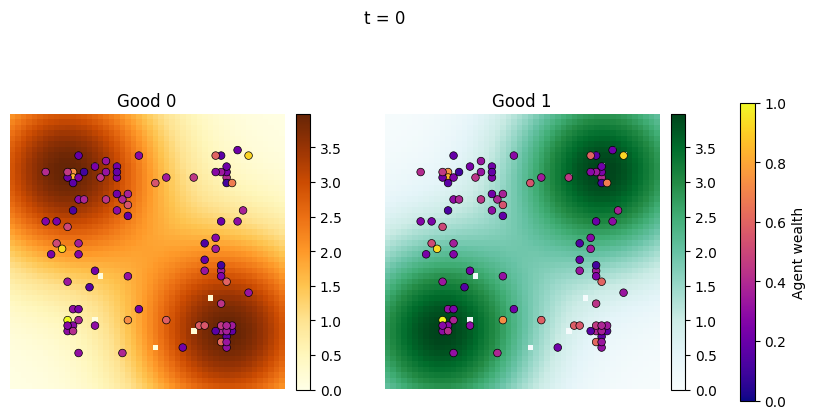

In [40]:
seed = 1


df, agents_history, env_history = run(
    time_steps=100,
    n_agents=100,
    env_size=(50, 50),
    resource_fns=make_anti_correlated_2good(50, 50),
    seed=seed,
    live=True,
    record=True
)

anim = animate(
    df,
    agents_history,
    env_history,
    save_path= f"output/model_run/run_seed{seed}.mp4" #f"output/model_run/run_seed{seed}.gif"   # or f"run_seed{seed}.mp4"
)

display(df)
